In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [ ]:
mnist = keras.datasets.mnist
(x_train,y_train), (x_test,y_test) = mnist.load_data()
x_train , x_test=x_train / 255.0, x_test/255.0 #we divide by 255.0 to normalise that is everthing becomes in the range of 0 to 1

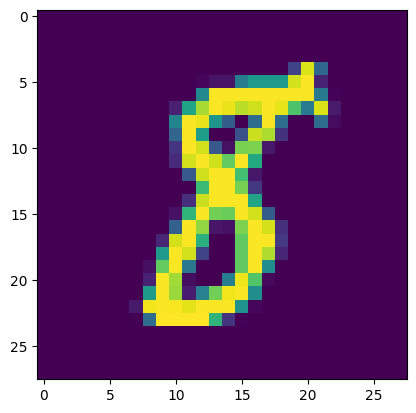

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x_train[125])

In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
y_train[125]

np.uint8(8)

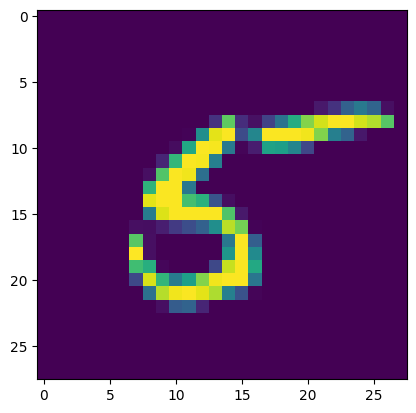

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x_train[1810])

In [ ]:
model = keras.Sequential([
    layers.Flatten(input_shape=(28,28,1)),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
outcome=model.fit(x_train,y_train,validation_split=0.1,epochs=10)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9194 - loss: 0.2812 - val_accuracy: 0.9633 - val_loss: 0.1343
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9636 - loss: 0.1236 - val_accuracy: 0.9735 - val_loss: 0.0981
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9751 - loss: 0.0841 - val_accuracy: 0.9747 - val_loss: 0.0869
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9813 - loss: 0.0617 - val_accuracy: 0.9780 - val_loss: 0.0729
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9855 - loss: 0.0480 - val_accuracy: 0.9792 - val_loss: 0.0769
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9884 - loss: 0.0376 - val_accuracy: 0.9783 - val_loss: 0.0799
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9908 - loss: 0.0299 - val_accuracy: 0.9785 - val_loss: 0.0775
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9926 - loss: 0.0238 - 

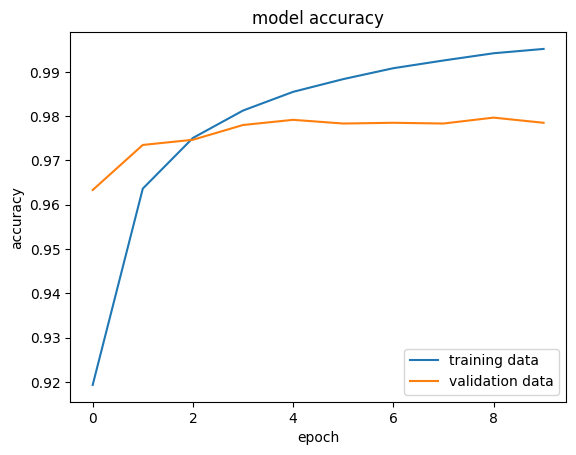

In [ ]:
plt.plot(outcome.history['accuracy'])
plt.plot(outcome.history['val_accuracy'])
plt.title("model accuracy")
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['training data','validation data'],loc='lower right')

In [ ]:
y_pred=model.predict(x_test)
y_pred[8888]

#when only ypred give ans will be in array if we give np then we will a number from 0 to 9


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([4.3641566e-11, 2.7211580e-13, 1.3855624e-09, 5.5132555e-11,
       3.6612582e-09, 7.6508394e-10, 9.9999994e-01, 2.9980103e-17,
       1.5749922e-11, 1.1557137e-15], dtype=float32)

In [ ]:
import numpy as np
y_pred1=np.argmax(y_pred,axis=1)#argmax-conv array into numbers
y_pred1[1210]

np.int64(2)

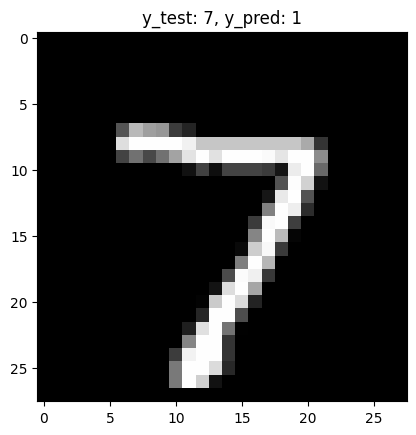

In [ ]:
import matplotlib.pyplot as plt

# Let's pick an image to display, for example, the first image from the test set
image_index = 0
plt.imshow(x_test[image_index], cmap='gray') # Use cmap='gray' for grayscale images
plt.title(f"y_test: {y_test[0]}, y_pred: {y_pred1[2]}")
plt.show()

Next, we'll preprocess the uploaded image to match the format expected by our model. This includes resizing it to 28x28 pixels, converting it to grayscale, and normalizing the pixel values.

Preprocessed image shape: (1, 28, 28)


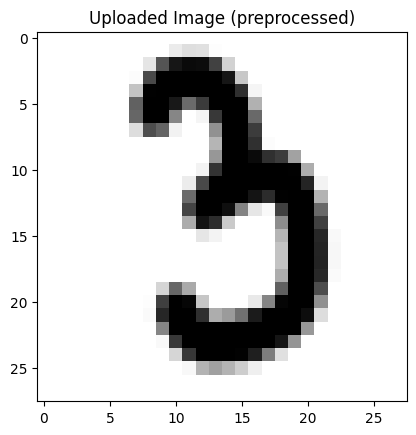

In [ ]:
from PIL import Image



img = Image.open("/content/Screenshot 2026-06-04 112228.png").convert('L') # Convert to grayscale


img = img.resize((28, 28))


img_array = np.asarray(img)
img_array = img_array / 255.0 # Normalize to 0-1 range


img_input = img_array.reshape(1, 28, 28)

print("Preprocessed image shape:", img_input.shape)


plt.imshow(img_input[0], cmap='gray')
plt.title("Uploaded Image (preprocessed)")
plt.show()

Now, let's use our trained model to predict the digit in your uploaded image.

In [ ]:
# Make a prediction
prediction = model.predict(img_input)

# Get the predicted digit (the one with the highest probability)
predicted_digit = np.argmax(prediction)

print(f"The model predicts this image is a: {predicted_digit}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
The model predicts this image is a: 7


In [ ]:
#saving a model
model.save("handwritten_digit_model.h5")